['idle', 'running', 'stairs', 'walking']
idle 1039
running 3408
stairs 165
walking 1850
Raw features: (6462, 90)
Time-domain features: (6462, 15)
Target: (6462,)
RAW train: (5169, 90)
RAW test: (1293, 90)
TIME train: (5169, 15)
TIME test: (1293, 15)
y train: (5169,)
y test: (1293,)
SVM + RAW FEATURES
              precision    recall  f1-score   support

        idle       1.00      1.00      1.00       208
     running       1.00      1.00      1.00       682
      stairs       0.93      0.42      0.58        33
     walking       0.95      1.00      0.97       370

    accuracy                           0.98      1293
   macro avg       0.97      0.86      0.89      1293
weighted avg       0.98      0.98      0.98      1293

SVM + TIME-DOMAIN FEATURES
              precision    recall  f1-score   support

        idle       1.00      1.00      1.00       208
     running       1.00      1.00      1.00       682
      stairs       0.93      0.76      0.83        33
     walking       

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


RANDOM FOREST + TIME-DOMAIN FEATURES
              precision    recall  f1-score   support

        idle       1.00      1.00      1.00       208
     running       1.00      1.00      1.00       682
      stairs       1.00      0.97      0.98        33
     walking       1.00      1.00      1.00       370

    accuracy                           1.00      1293
   macro avg       1.00      0.99      1.00      1293
weighted avg       1.00      1.00      1.00      1293



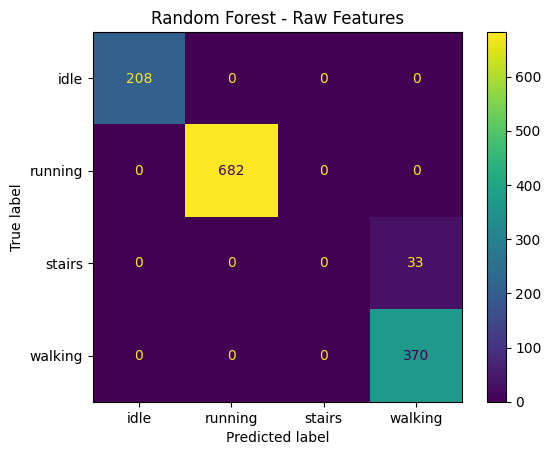

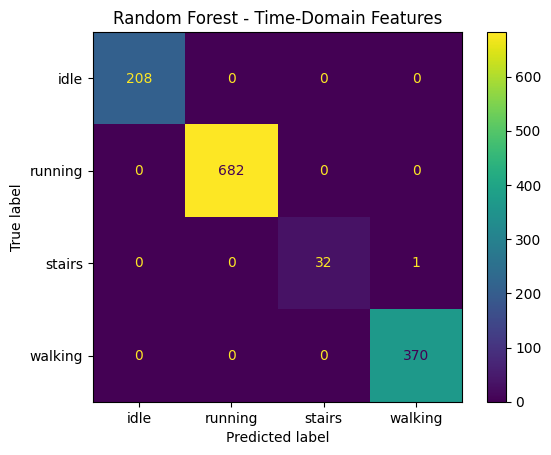

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,SVM Raw,SVM Time,RF Raw,RF Time
Accuracy,0.98,0.99,0.97,1.00
Macro Precision,0.97,0.98,0.73,1.00
Macro Recall,0.86,0.94,0.75,0.99
Macro F1,0.89,0.95,0.74,1.00
Stairs Precision,0.93,0.93,0.00,1.00
Stairs Recall,0.42,0.76,0.00,0.97
Stairs F1,0.58,0.83,0.00,0.98


In [2]:
# ============================================
# 1. IMPORTS
# ============================================

import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


# ============================================
# 2. UNPACK DATASET
# ============================================

shutil.unpack_archive(
    "/content/homework.zip",
    "/content/homework"
)

base_path = "/content/homework/data"


# ============================================
# 3. CHECK CLASSES
# ============================================

classes = sorted(os.listdir(base_path))

print(classes)


# ============================================
# 4. CREATE RAW FEATURES + TIME-DOMAIN FEATURES
#    IN ONE PASS THROUGH ALL FILES
# ============================================

raw_features_list = []
time_features_list = []
labels = []
file_ids = []

for activity in classes:
    folder_path = os.path.join(base_path, activity)

    files = [
        file
        for file in sorted(os.listdir(folder_path))
        if file.endswith(".csv")
    ]

    print(activity, len(files))

    for file in files:
        file_path = os.path.join(folder_path, file)

        df = pd.read_csv(file_path)

        # ------------------------
        # RAW FEATURES
        # 30 x 3 -> 90 features
        # ------------------------

        raw_features = df.to_numpy().flatten()
        raw_features_list.append(raw_features)

        # ------------------------
        # TIME-DOMAIN FEATURES
        # 5 features for X
        # 5 features for Y
        # 5 features for Z
        # total = 15
        # ------------------------

        time_features = {}

        for column in df.columns:
            time_features[f"{column}_mean"] = df[column].mean()
            time_features[f"{column}_std"] = df[column].std()
            time_features[f"{column}_min"] = df[column].min()
            time_features[f"{column}_max"] = df[column].max()
            time_features[f"{column}_median"] = df[column].median()

        time_features_list.append(time_features)

        # target
        labels.append(activity)

        # keep file name for control
        file_ids.append(f"{activity}/{file}")


# ============================================
# 5. CREATE X_raw, X_time AND y
# ============================================

X_raw = np.array(raw_features_list)

X_time = pd.DataFrame(time_features_list)

y = np.array(labels)


print("Raw features:", X_raw.shape)
print("Time-domain features:", X_time.shape)
print("Target:", y.shape)

X_time.head()


# ============================================
# 6. ONE COMMON TRAIN/TEST SPLIT
# ============================================

indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# RAW data

X_raw_train = X_raw[train_idx]
X_raw_test = X_raw[test_idx]


# TIME-DOMAIN data

X_time_train = X_time.iloc[train_idx]
X_time_test = X_time.iloc[test_idx]


# SAME y FOR BOTH FEATURE SETS

y_train = y[train_idx]
y_test = y[test_idx]


print("RAW train:", X_raw_train.shape)
print("RAW test:", X_raw_test.shape)

print("TIME train:", X_time_train.shape)
print("TIME test:", X_time_test.shape)

print("y train:", y_train.shape)
print("y test:", y_test.shape)


# ============================================
# 7. SVM + RAW FEATURES
# ============================================

scaler_raw = StandardScaler()

X_raw_train_scaled = scaler_raw.fit_transform(X_raw_train)
X_raw_test_scaled = scaler_raw.transform(X_raw_test)

svm_raw_model = SVC()

svm_raw_model.fit(
    X_raw_train_scaled,
    y_train
)

y_pred_svm_raw = svm_raw_model.predict(
    X_raw_test_scaled
)

print("SVM + RAW FEATURES")
print(
    classification_report(
        y_test,
        y_pred_svm_raw
    )
)


# ============================================
# 8. SVM + TIME-DOMAIN FEATURES
# ============================================

scaler_time = StandardScaler()

X_time_train_scaled = scaler_time.fit_transform(
    X_time_train
)

X_time_test_scaled = scaler_time.transform(
    X_time_test
)

svm_time_model = SVC()

svm_time_model.fit(
    X_time_train_scaled,
    y_train
)

y_pred_svm_time = svm_time_model.predict(
    X_time_test_scaled
)

print("SVM + TIME-DOMAIN FEATURES")
print(
    classification_report(
        y_test,
        y_pred_svm_time
    )
)


# ============================================
# 9. RANDOM FOREST + RAW FEATURES
# ============================================

rf_raw_model = RandomForestClassifier(
    random_state=42
)

rf_raw_model.fit(
    X_raw_train,
    y_train
)

y_pred_rf_raw = rf_raw_model.predict(
    X_raw_test
)

print("RANDOM FOREST + RAW FEATURES")
print(
    classification_report(
        y_test,
        y_pred_rf_raw
    )
)


# ============================================
# 10. RANDOM FOREST + TIME-DOMAIN FEATURES
# ============================================

rf_time_model = RandomForestClassifier(
    random_state=42
)

rf_time_model.fit(
    X_time_train,
    y_train
)

y_pred_rf_time = rf_time_model.predict(
    X_time_test
)

print("RANDOM FOREST + TIME-DOMAIN FEATURES")
print(
    classification_report(
        y_test,
        y_pred_rf_time
    )
)


# ============================================
# 11. CONFUSION MATRIX:
#     RANDOM FOREST + RAW
# ============================================

cm_rf_raw = confusion_matrix(
    y_test,
    y_pred_rf_raw
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_raw,
    display_labels=rf_raw_model.classes_
)

disp.plot()
plt.title("Random Forest - Raw Features")
plt.show()


# ============================================
# 12. CONFUSION MATRIX:
#     RANDOM FOREST + TIME-DOMAIN
# ============================================

cm_rf_time = confusion_matrix(
    y_test,
    y_pred_rf_time
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_time,
    display_labels=rf_time_model.classes_
)

disp.plot()
plt.title("Random Forest - Time-Domain Features")
plt.show()


# ============================================
# 13. GET REPORTS AS DICTIONARIES
# ============================================

report_svm_raw = classification_report(
    y_test,
    y_pred_svm_raw,
    output_dict=True
)

report_svm_time = classification_report(
    y_test,
    y_pred_svm_time,
    output_dict=True
)

report_rf_raw = classification_report(
    y_test,
    y_pred_rf_raw,
    output_dict=True
)

report_rf_time = classification_report(
    y_test,
    y_pred_rf_time,
    output_dict=True
)


# ============================================
# 14. FINAL COMPARISON TABLE
# ============================================

results = pd.DataFrame(
    {
        "SVM Raw": [
            report_svm_raw["accuracy"],
            report_svm_raw["macro avg"]["precision"],
            report_svm_raw["macro avg"]["recall"],
            report_svm_raw["macro avg"]["f1-score"],
            report_svm_raw["stairs"]["precision"],
            report_svm_raw["stairs"]["recall"],
            report_svm_raw["stairs"]["f1-score"],
        ],

        "SVM Time": [
            report_svm_time["accuracy"],
            report_svm_time["macro avg"]["precision"],
            report_svm_time["macro avg"]["recall"],
            report_svm_time["macro avg"]["f1-score"],
            report_svm_time["stairs"]["precision"],
            report_svm_time["stairs"]["recall"],
            report_svm_time["stairs"]["f1-score"],
        ],

        "RF Raw": [
            report_rf_raw["accuracy"],
            report_rf_raw["macro avg"]["precision"],
            report_rf_raw["macro avg"]["recall"],
            report_rf_raw["macro avg"]["f1-score"],
            report_rf_raw["stairs"]["precision"],
            report_rf_raw["stairs"]["recall"],
            report_rf_raw["stairs"]["f1-score"],
        ],

        "RF Time": [
            report_rf_time["accuracy"],
            report_rf_time["macro avg"]["precision"],
            report_rf_time["macro avg"]["recall"],
            report_rf_time["macro avg"]["f1-score"],
            report_rf_time["stairs"]["precision"],
            report_rf_time["stairs"]["recall"],
            report_rf_time["stairs"]["f1-score"],
        ],
    },

    index=[
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Stairs Precision",
        "Stairs Recall",
        "Stairs F1",
    ]
)

results.round(2)

## Візуалізація

### Розподіл класів

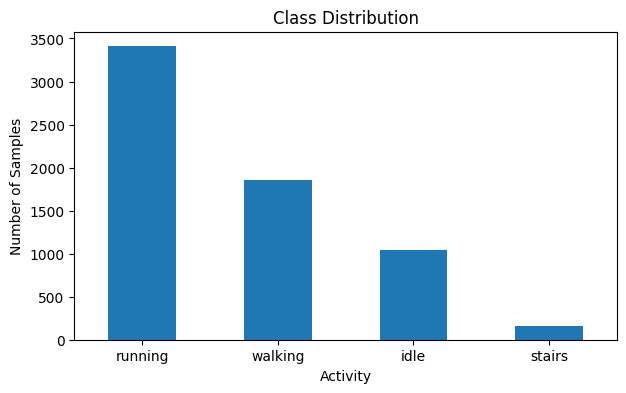

In [3]:
class_counts = pd.Series(y).value_counts()

plt.figure(figsize=(7, 4))
class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
# plt.xticks(rotation=0)
plt.show()

### Порівняння наших чотирьох експериментів

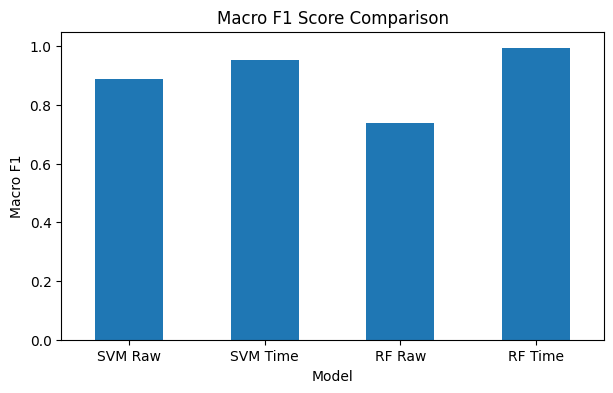

In [4]:
macro_f1 = results.loc["Macro F1"]

plt.figure(figsize=(7, 4))
macro_f1.plot(kind="bar")

plt.title("Macro F1 Score Comparison")
plt.ylabel("Macro F1")
plt.xlabel("Model")
plt.ylim(0, 1.05)
# plt.xticks(rotation=0)
plt.show()

### Feature Importance Random Forest

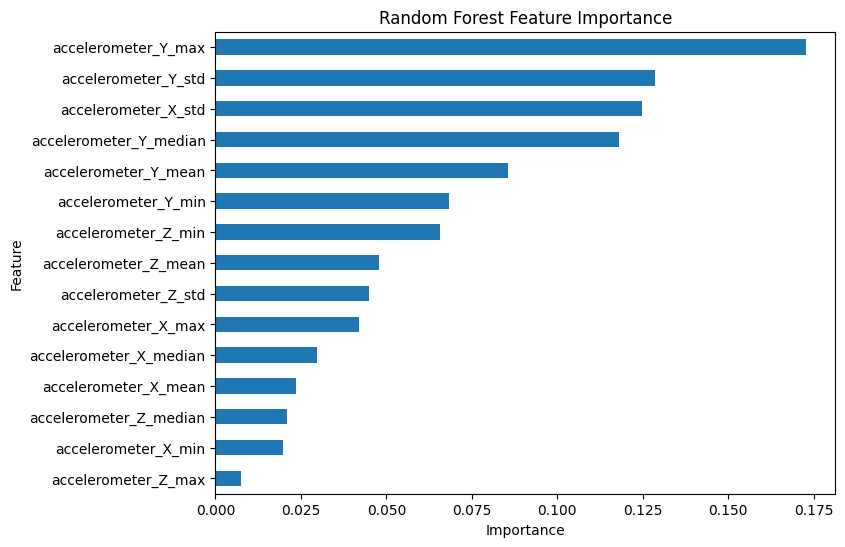

In [5]:
feature_importance = pd.Series(
    rf_time_model.feature_importances_,
    index=X_time.columns
)

plt.figure(figsize=(8, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()